<a href="https://colab.research.google.com/github/Pallavi20004/Demo/blob/main/Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baseline Model Accuracy: 0.80
Baseline Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.85      0.82        80
           1       0.79      0.73      0.76        63

    accuracy                           0.80       143
   macro avg       0.80      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30, 'bootstrap': False}

Optimized Model Accuracy: 0.80
Optimized Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.89      0.83        80
           1       0.83      0.68      0.75        63

    accuracy                           0.80       143
   macro avg       0.80      0.79      0.79       143
weighted avg       0.80      0.80      0.79       143



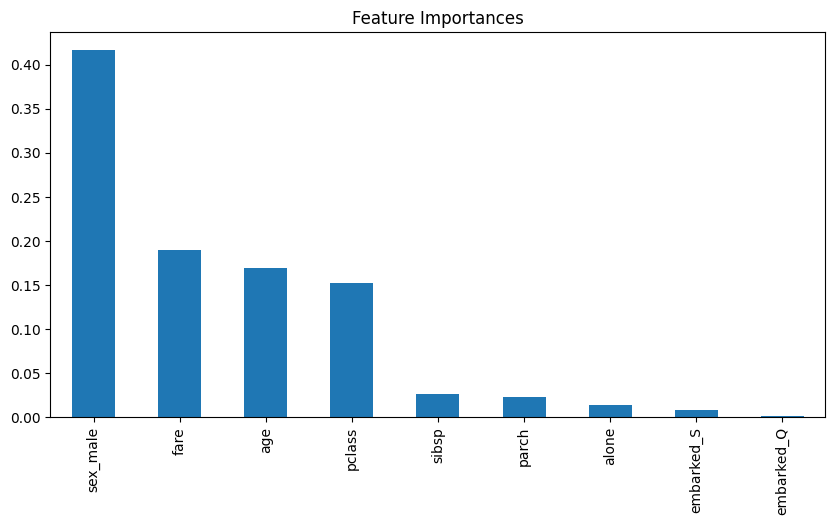

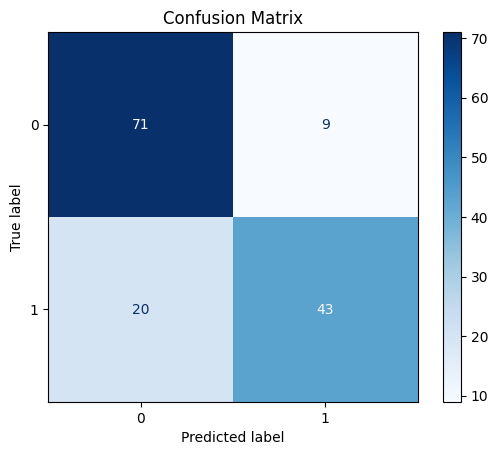

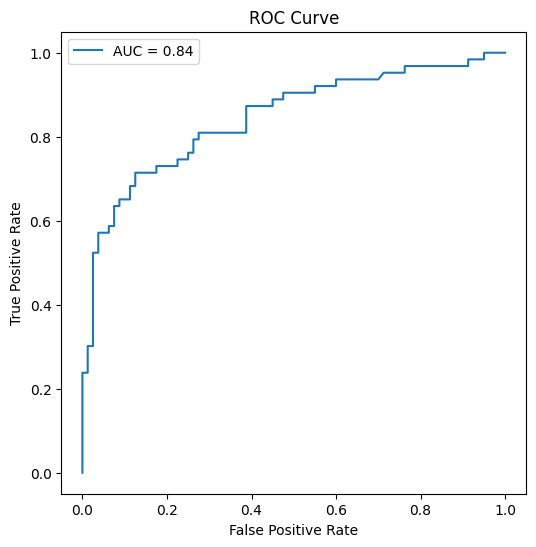

In [ ]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Data Preprocessing
titanic.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], axis=1, inplace=True)
titanic.dropna(inplace=True)  # Drop rows with missing values
titanic = pd.get_dummies(titanic, drop_first=True)  # Convert categorical variables into dummy variables

# Split data into features (X) and target (y)
X = titanic.drop('survived', axis=1)
y = titanic['survived']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Train a Baseline Random Forest Model
baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# Evaluate Baseline Model
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Model Accuracy: {baseline_accuracy:.2f}")
print("Baseline Classification Report:\n", classification_report(y_test, y_pred_baseline))

# 2. Hyperparameter Tuning with RandomizedSearchCV
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Use RandomizedSearchCV to find the best hyperparameters
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,  # Number of different combinations to try
    cv=5,  # Cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Display best hyperparameters
print("\nBest Hyperparameters:", random_search.best_params_)

# 3. Train and Evaluate Optimized Model
best_model = random_search.best_estimator_
y_pred_optimized = best_model.predict(X_test)

# Evaluate Optimized Model
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
print(f"\nOptimized Model Accuracy: {optimized_accuracy:.2f}")
print("Optimized Classification Report:\n", classification_report(y_test, y_pred_optimized))

# 4. Feature Importance Plot
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5), title="Feature Importances")
plt.show()

# 5. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred_optimized)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# 6. ROC Curve & AUC Score
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")
plt.show()
